In [9]:
import numpy as np
import matplotlib.pyplot as plt

# The editable install means we can import this anywhere, no sys.path hacks needed.
import cosmo_sim_tools as cosmosim

# NOTE: importing the top-level package does NOT pull in the subpackages,
# so we import the helpers explicitly:
from cosmo_sim_tools.arepo_tools import arepo_package as arepo
from cosmo_sim_tools import illustris as il
from cosmo_sim_tools import brahma
from scipy.spatial.distance import cdist

In [10]:
Brahma_sim_path = '/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/'
Brahma_sim_name = 'SM5_DFD_3_TNG/'
Brahma_sim_file = Brahma_sim_path+Brahma_sim_name

In [11]:
brahma_snapshots,brahma_redshifts = arepo.get_snapshot_redshift_correspondence(Brahma_sim_file)

In [12]:
snap = brahma_snapshots[0]
header  = brahma.groupcat.loadHeader(Brahma_sim_file, snap)
h       = header['HubbleParam']
boxsize = header['BoxSize']

In [13]:
snap_i = brahma_snapshots[-1]
subhalos = brahma.groupcat.loadSubhalos(Brahma_sim_file, snap_i, fields=['SubhaloLenType','SubhaloPos','SubhaloGrNr'])
subhalo_index = 0                        
n_bh = subhalos['SubhaloLenType'][subhalo_index,5]  
print(f"snapshot {snap_i}: subhalo {subhalo_index} has {n_bh} black hole(s) ")

snapshot 32: subhalo 0 has 1376 black hole(s) 


In [32]:
snap_i = brahma_snapshots[-1]
z_i = brahma_redshifts[-1]
subhalos = brahma.groupcat.loadSubhalos(Brahma_sim_file, snap_i, fields=['SubhaloLenType','SubhaloPos','SubhaloGrNr'])


si = 0                       
n_bh = subhalos['SubhaloLenType'][subhalo_index,5]  
subhalo_center = subhalos['SubhaloPos'][subhalo_index]

MBH_coordinates = arepo.get_particle_property_within_postprocessed_groups(Brahma_sim_file,particle_property=['Coordinates'],p_type=5,desired_redshift=z_i,subhalo_index=si,group_type='subhalo')
MBH_masses = arepo.get_particle_property_within_postprocessed_groups(Brahma_sim_file,particle_property=['BH_Mass'],p_type=5,desired_redshift=z_i,subhalo_index=si,group_type='subhalo')

MBH_distance_from_center = cdist(MBH_coordinates[0], subhalo_center.reshape(1, -1))/h #ckpc
BH_masses_in_subhalo = MBH_masses[0] * 1e10/h #Msun

offsets were already there
offsets were already there


Text(0.5, 1.0, 'snapshot 32: subhalo 0 has 1376 black hole(s) ')

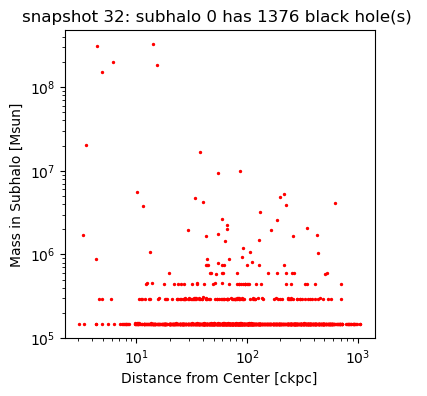

In [35]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
ax.scatter(MBH_distance_from_center,BH_masses_in_subhalo,color='r',s=2)
ax.set_xlabel('Distance from Center [ckpc]')
ax.set_ylabel('Mass in Subhalo [Msun]')
ax.set_xscale('log',base=10)
ax.set_yscale('log',base=10)
ax.set_ylim(1e5,)
ax.set_title(f"snapshot {snap_i}: subhalo {subhalo_index} has {n_bh} black hole(s) ")